### Import Modelling Libraries

In [1]:
# Core
import time
from pathlib import Path
import joblib

# Data
import pandas as pd
import numpy as np

# Models (sklearn + others)
from sklearn.ensemble import RandomForestClassifier
# External gradient boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Label mapping
LABEL_NAMES = {
    0: "Normal",
    1: "Leak",
    2: "Blockage"
}

# Paths
BASE_PATH   = Path.cwd().parent.parent
SCALED_PATH = BASE_PATH / "data" / "model-live" / "scaled"
MODEL_PATH  = BASE_PATH / "models"
ASSETS_PATH = BASE_PATH/ "assets" /"live"
artifacts_path = Path.cwd().parent.parent / "artifacts"
artifacts_path.mkdir(parents=True, exist_ok=True)

MODEL_PATH.mkdir(parents=True, exist_ok=True)

print("Imports & config loaded.")


Imports & config loaded.


### Load Scaled Data

In [2]:
# Load data that has been scaled.
# Loading the Robust Scaled data and then, switch to Standard Scaled data later for comparison.

# Load scaled data (ROBUST versions)
X_train = pd.read_csv(SCALED_PATH / "X_train_robust_live_data.csv")
X_val   = pd.read_csv(SCALED_PATH / "X_val_robust_live_data.csv")
X_test  = pd.read_csv(SCALED_PATH / "X_test_robust_live_data.csv")

y_train = pd.read_csv(SCALED_PATH / "y_train_live.csv").squeeze()
y_val   = pd.read_csv(SCALED_PATH / "y_val_live.csv").squeeze()
y_test  = pd.read_csv(SCALED_PATH / "y_test_live.csv").squeeze()

# Verify shapes
print("DATA SHAPES")
print("-" * 30)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Verify label balance
print("\nLABEL DISTRIBUTION")
print("-" * 30)
print("Train:\n", y_train.value_counts())
print("\nVal:\n", y_val.value_counts())
print("\nTest:\n", y_test.value_counts())

DATA SHAPES
------------------------------
X_train: (113562, 51) | y_train: (113562,)
X_val  : (18927, 51)   | y_val  : (18927,)
X_test : (18927, 51)  | y_test : (18927,)

LABEL DISTRIBUTION
------------------------------
Train:
 label
2    37854
1    37854
0    37854
Name: count, dtype: int64

Val:
 label
2    6309
1    6309
0    6309
Name: count, dtype: int64

Test:
 label
2    6309
1    6309
0    6309
Name: count, dtype: int64


# Define model pipelines

In [3]:
# Pipeline builder
def build_pipeline(model_name, estimator):
    return Pipeline([
        ("classifier", estimator)
    ])
CW = {0: 1.8, 1: 1.0, 2: 1.5}  # Normal boosted

MODELS = {
    "random_forest": build_pipeline(
        "rf",
        RandomForestClassifier(
            n_estimators=200,
            class_weight=CW,
            n_jobs=-1,
            random_state=42
        )
    ),

    "xgboost": build_pipeline(
        "xgb",
        XGBClassifier(
            n_estimators = 200,
            learning_rate = 0.1,
            num_class = 3,
            objective="multi:softmax",
            eval_metric = "mlogloss",
            scale_pos_weight=None,
            n_jobs=-1,
            random_state=42
        )
    ),

    # Linear svc does not use kernel
    "lightgbm": build_pipeline(
        "lgbm",
        LGBMClassifier(
            n_estimators=200,
            n_jobs=-1,
            random_state=42,
            learning_rate=0.1,
            num_leaves=31,
            num_class=3,
            objective = "multiclass",
            class_weight=CW,
            min_child_samples=20,
            verbose =-1

        )
    )
}

print(f"Defined {len(MODELS)} models:")
for name in MODELS.keys():
    print(f"- {name}")

Defined 3 models:
- random_forest
- xgboost
- lightgbm


### Light GBM
- It is an ensemble method that uses gradient boosting method which constructs a string learner by sequentially adding weak learners in a gradient manner
- It is designed for its scalability, efficiency and high accuracy esp with large datasets.
- It decision trees that grow efficiently by minimizing memory usage and optimizing time.
- The differene with xgboost is that thgis prioritizes leaf growth over level wise growth

#### Support Vector Machine
The key idea behind the SVM algorithm is to find the hyperplane that best separates two classes by maximizing the margin between them. This margin is the distance from the hyperplane to the nearest data points (support vectors) on each side.

- Support vectors: The closest data points to the hyperplane, crucial for determining he hyper plane and the margins in SVM
- Kernel: A function that maps the data to higher dimensional space enabling SVM to handle non-linearly separable data.
- Hard Margin: A maximum-margin hyperplane that perfectly separates the data without misclassifications.
- Hyperplane: A decision boundary separating different classes in feature space and is represented by the equation wx + b = 0 in linear classification.
- Hinge Loss: A loss function penalizing misclassified points or margin violations and is combined with regularization in SVM. If the data is well classified then there are no penalties introduced.
- C: The regularization parameter that controls the trade-off between margin and misclassification error.

### Train the Models

In [4]:
# Training the six models
trained_models = {}
training_times = {}

for model_name, estimator in MODELS.items():
    print(f"Training.......{model_name}")

    start = time.time()
    estimator.fit(X_train, y_train)
    elapsed = time.time() - start

    trained_models[model_name] = estimator
    training_times[model_name] = elapsed

    print(f"Done in {elapsed:.2f} seconds.")

print("\n All Models Trained")
print(training_times)


Training.......random_forest
Done in 23.63 seconds.
Training.......xgboost
Done in 5.07 seconds.
Training.......lightgbm
Done in 11.10 seconds.

 All Models Trained
{'random_forest': 23.625786781311035, 'xgboost': 5.069308042526245, 'lightgbm': 11.0961332321167}


### Evaluate All on Validation Set

In [5]:
# Evaluate the models
val_results = {}

for model_name, model in trained_models.items():

    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    leak_f1 = f1_score(y_val, y_pred, average=None)[1]

    report_dict = classification_report(y_val, y_pred, output_dict=True)
    leak_recall = report_dict["1"]["recall"]

    val_results[model_name] = {
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "leak_f1": round(leak_f1, 4),
        "leak_recall": round(leak_recall, 4),
        "train_time_s": training_times[model_name]
    }

    print(f"\n{'='*40}")
    print(f"MODEL: {model_name}")
    print(classification_report(
        y_val, y_pred,
        target_names=["Normal", "Leak", "Blockage"]
    ))

    if leak_recall < 0.70:
        print(f"WARNING: Leak recall = {leak_recall:.2f} — below 0.70")

print("\nValidation Summary:")
print(pd.DataFrame(val_results).T.sort_values(by="macro_f1", ascending=False))


MODEL: random_forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6309
        Leak       1.00      1.00      1.00      6309
    Blockage       1.00      1.00      1.00      6309

    accuracy                           1.00     18927
   macro avg       1.00      1.00      1.00     18927
weighted avg       1.00      1.00      1.00     18927


MODEL: xgboost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6309
        Leak       1.00      1.00      1.00      6309
    Blockage       1.00      1.00      1.00      6309

    accuracy                           1.00     18927
   macro avg       1.00      1.00      1.00     18927
weighted avg       1.00      1.00      1.00     18927


MODEL: lightgbm
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6309
        Leak       1.00      1.00      1.00      6309
    Blockage       1

- Normal precision = 1.00,  when it DOES predict Normal, it's always right. Normal is a real distinct class.
- Normal recall = 0.23, but it almost never predicts Normal. It sees a sample that should be Normal and calls it Leak instead.

In [6]:
print(trained_models["random_forest"].named_steps["classifier"].class_weight)

{0: 1.8, 1: 1.0, 2: 1.5}


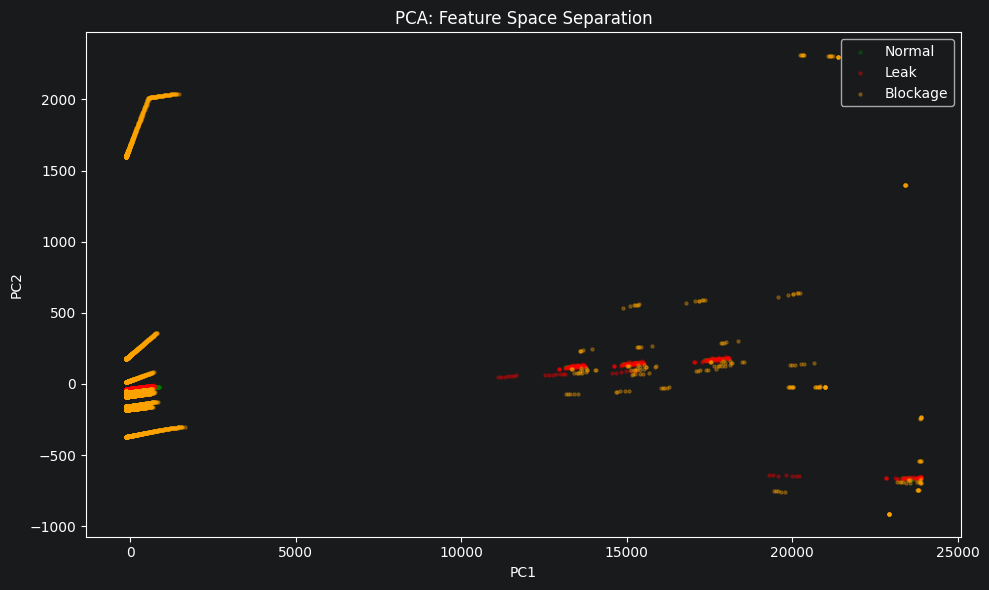

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)

plt.figure(figsize=(10, 6))
colors = {0: "green", 1: "red", 2: "orange"}
labels = {0: "Normal", 1: "Leak", 2: "Blockage"}

for cls in [0, 1, 2]:
    mask = y_train == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cls], label=labels[cls],
                alpha=0.3, s=5)

plt.legend()
plt.title("PCA: Feature Space Separation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(ASSETS_PATH / "pca_class_separation.png", dpi=150)
plt.show()

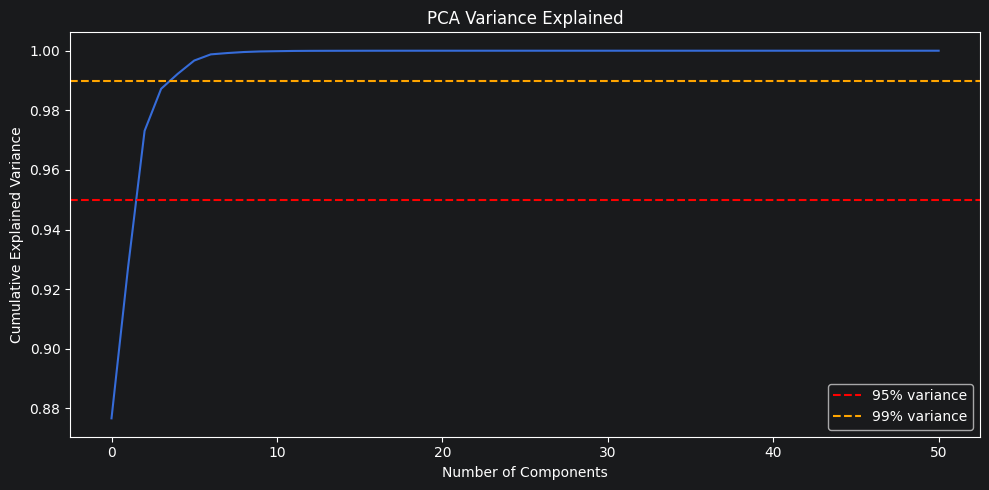

Components for 95% variance: 3
Components for 99% variance: 5


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumvar)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axhline(0.99, color='orange', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS_PATH / "pca_variance.png", dpi=150)
plt.show()

print(f"Components for 95% variance: {np.argmax(cumvar >= 0.95) + 1}")
print(f"Components for 99% variance: {np.argmax(cumvar >= 0.99) + 1}")

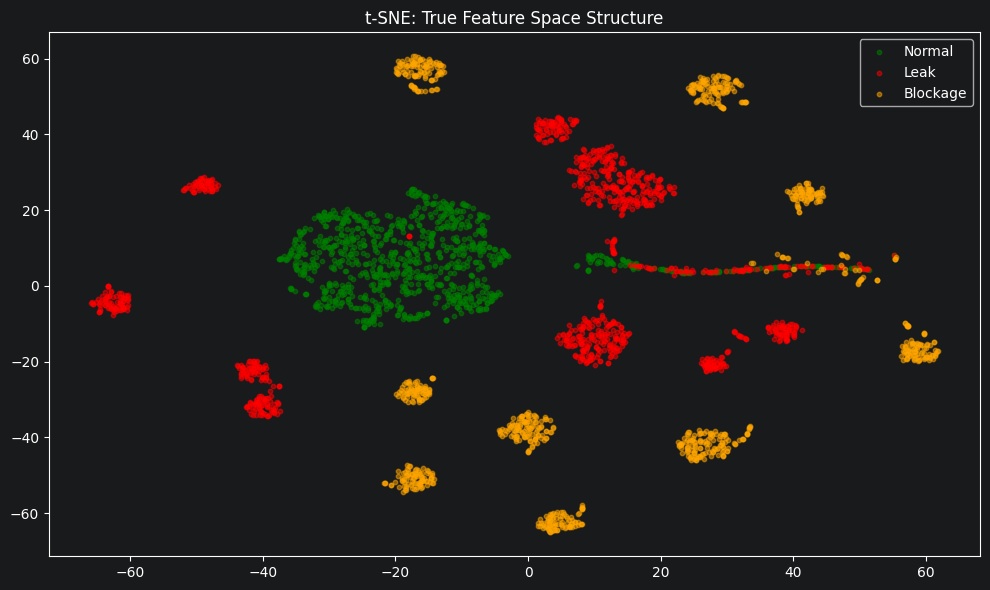

In [9]:
from sklearn.manifold import TSNE

# Use a sample — t-SNE is slow on full dataset
sample_idx = np.random.choice(len(X_train), 3000, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
colors = {0: "green", 1: "red", 2: "orange"}
labels_map = {0: "Normal", 1: "Leak", 2: "Blockage"}

for cls in [0, 1, 2]:
    mask = y_sample.values == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.5, s=10)

plt.legend()
plt.title("t-SNE: True Feature Space Structure")
plt.tight_layout()
plt.savefig(ASSETS_PATH / "tsne_separation.png", dpi=150)
plt.show()

### Save models

In [10]:
# Save random forest
joblib.dump(
    trained_models["random_forest"],
    artifacts_path / "random_forest_live.joblib"
)

# Save xgboost
joblib.dump(
    trained_models["xgboost"],
    artifacts_path / "xgboost_live.joblib"
)

# Save lightgbm
joblib.dump(
    trained_models["lightgbm"],
    artifacts_path / "lightgbm_live.joblib"
)

print("All models saved to ml_service/artifacts/")
print(f"RF size: {(artifacts_path / 'random_forest_live.joblib').stat().st_size / 1e6:.1f} MB")

All models saved to ml_service/artifacts/
RF size: 2.1 MB
